# Exercise 6: Markov Chain Monte Carlo

In [1]:
import numpy as np
import math
from scipy.stats import chisquare
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

## 6.1) 
Generating values from a truncated Poisson distribution by applying the Metropolis-Hastings algorithm, and verifying with a Chi-square test

In [2]:
# Define parameters (from exercise 4)
A = 8
m = 10
N = 100000
burn_in = N // 2       # States to discard at the start

np.random.seed(4223)


# Define the unnormalized target distribution
def g(i):
    if i < 0 or i > m:  # for i=0,...,m
        return 0.0
    return (A**i) / math.factorial(i)


# Run Metropolis Hastings
samples = []    # Initilize an empty list to store the samples in
current_state = 0   # Initial state

for _ in range(N):
    # Propose a candidate state (Random walk: +1 or -1)
    step = np.random.choice([-1, 1])
    proposed_state = current_state + step
    
    # Calculate acceptance probability
    if proposed_state < 0 or proposed_state > m:   # If outside the bounds
        alpha = 0.0 # Reject out of bounds proposals
    else:
        alpha = min(1.0, g(proposed_state) / g(current_state))  # accept with probability g(y)/g(x)
        
    # Accept or reject
    u = np.random.rand()    # Random number between 0 and 1
    if u < alpha:
        current_state = proposed_state # Accept move
        
    # Appent the new state
    samples.append(current_state)

# Discard the burn-in period
valid_samples = samples[burn_in:]


In [3]:
# Calculate observed frequencies from MCMC
observed_counts = np.zeros(m + 1)   # The Poisson system can take values from 0 to m
for sample in valid_samples:    # Loops though every visited state of the Markov chain
    observed_counts[sample] += 1

# Calculate exact theoretical probabilities
g_unnormalized = [g(i) for i in range(m + 1)]
c = 1.0 / sum(g_unnormalized) # The normalizing constant (the probabilities must sum to 1)
theoretical_probs = [c * val for val in g_unnormalized]

# Calculate expected frequencies
expected_counts = np.array(theoretical_probs) * len(valid_samples)

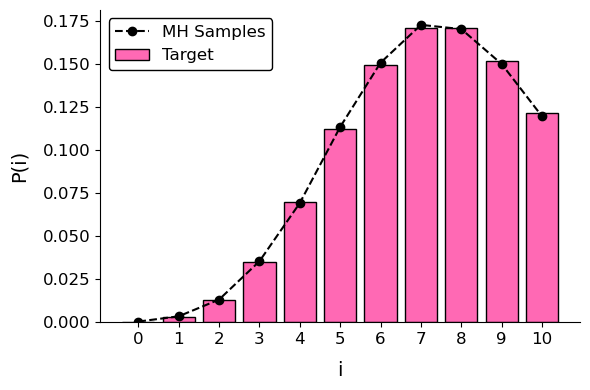

In [4]:
# Plotting the true distribution and the samples

# Convert the raw counts from the MCMC simulation into probabilities
mh_probs = observed_counts / len(valid_samples)

# The range of the x-axis
x_vals = np.arange(m + 1)

# Create the plot
plt.figure(figsize=(6, 4))

# Plotingt the target theoretical distribution as a histogram
plt.bar(x_vals, theoretical_probs, color='hotpink', edgecolor='black', label='Target')

# Plot the samples as a line with markers
plt.plot(x_vals, mh_probs, color='black', marker='o', linestyle='--', label='MH Samples')

# Formatting the plot
plt.xlabel('i', fontsize=14, labelpad=10)
plt.ylabel('P(i)', fontsize=14, labelpad=10)

plt.xticks(x_vals, fontsize=12) 
plt.yticks(fontsize=12)

# Add the legend in the top left corner
plt.legend(fontsize=12, loc='upper left', framealpha=1, edgecolor='black')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Display the plot
plt.tight_layout()
plt.show()

The plot indicates that the fit is quite good. 

The Chi-square test assumes that all samples are independent. However, samples generated via MCMC are autocorrelated (each state depends on the previous one). To perform a valid statistical test, we therefore first thin the chain to obtain independent samples. We start by plotting the ACF to see how many samples to thin out.

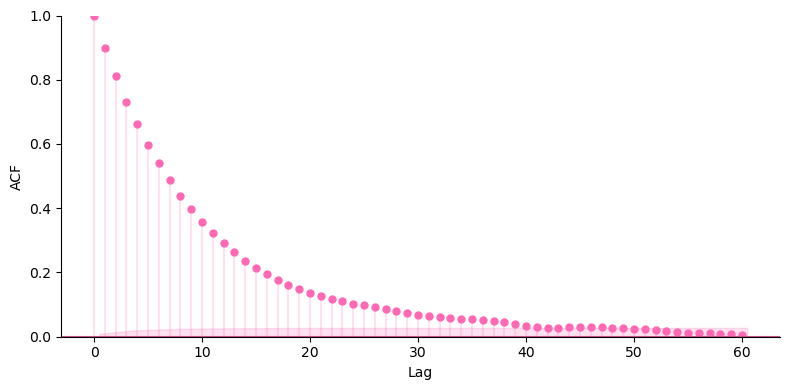

In [5]:
# Plot the autocorrelation function (ACF)
fig, ax = plt.subplots(figsize=(8, 4))
plot_acf(valid_samples, lags=60, ax=ax, alpha=0.05)

# Change colors
for line in ax.lines:
    line.set_color("hotpink")

for collection in ax.collections:
    collection.set_color("hotpink")
    collection.set_alpha(0.2)

ax.set_title("")
plt.xlabel("Lag")
plt.ylabel("ACF")

# Add a horizontal line at 0 for easy reading
plt.axhline(0, color='black', linewidth=1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# No need to show the negative y-axis
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

The plot shows the autocorrelation for the MCMC samples. Wee see thay they come inside the confidence interval at lag 50, therefore we thin by taking only every 50 sample

In [6]:
# Thin the samples to remove autocorrelation 
thin_interval = 50  # Keep only 1 out of every 50 samples
thinned_samples = valid_samples[::thin_interval] 

print(f"Original valid samples: {len(valid_samples)}")
print(f"Thinned independent samples for testing: {len(thinned_samples)}")

# Calculate observed frequencies from the thinned MCMC
observed_counts = np.zeros(m + 1)
for sample in thinned_samples:
    observed_counts[sample] += 1

# Calculate exact theoretical probabilities
g_unnormalized = [g(i) for i in range(m + 1)]
c = 1.0 / sum(g_unnormalized) 
theoretical_probs = [c * val for val in g_unnormalized]

# Calculate expected frequencies using the thinned length
expected_counts = np.array(theoretical_probs) * len(thinned_samples)

# Perform the Chi-square test
chi2_stat, p_value = chisquare(f_obs=observed_counts, f_exp=expected_counts)

print(f"Chi^2 Statistic with thinning: {chi2_stat:.4f}")
print(f"p-value with thinning:        {p_value:.4f}")

Original valid samples: 50000
Thinned independent samples for testing: 1000
Chi^2 Statistic with thinning: 7.9973
p-value with thinning:        0.6291


## 6.2)

In [7]:
# Defining new parameters
A_1 = A_2 = 4
m = 10

# Defining the new unnormalized target distribution
def g(i):
    if i < 0 or i > m:  # for i=0,...,m
        return 0.0
    return (A**i) / math.factorial(i)

In [8]:
np.random.seed(4223)

# Defining the parameters
A1 = 4
A2 = 4
m = 10
N = 100000
burn_in = N // 2
thin_interval = 50  # Conservative thinning for 2D space

# Define the unnormalized 2D target distribution
def g2(i, j):
    if i < 0 or j < 0 or i + j > m: # Enforce the constraint: 0 <= i+j >= 10
        return 0.0
    return ((A1**i) / math.factorial(i)) * ((A2**j) / math.factorial(j))


In [9]:
# a) Defining a function to use Metropolis-Hastings directly 
def mh_direct(start_state):
    samples = np.zeros((N, 2), dtype=int)
    curr = np.array(start_state)
    dirs = np.array([[1, 0], [0, 1], [-1, 0], [0, -1]]) # Up, right, down, left
    
    for k in range(N):
        prop = curr + dirs[np.random.choice(4)]
        alpha = min(1, g2(prop[0], prop[1]) / g2(curr[0], curr[1]))   # If g2(curr) is 0, alpha is 0
        if np.random.rand() < alpha:
            curr = prop # move to the new position
        samples[k] = curr.copy()
    return samples

In [10]:
# b) Defining a function to use Metropolis-Hastings coordinate wise
def mh_coordinate(start_state):
    samples = np.zeros((N, 2), dtype=int)
    curr = np.array(start_state)
    
    for k in range(N):
        # Updating i (coordinate 1)
        prop_i = curr[0] + np.random.choice([-1, 1])
        alpha_i = min(1, g2(prop_i, curr[1]) / g2(curr[0], curr[1]))
        if np.random.rand() < alpha_i: 
            curr[0] = prop_i
            
        # Updating j (coordinate 2)
        prop_j = curr[1] + np.random.choice([-1, 1])
        alpha_j = min(1, g2(curr[0], prop_j) / g2(curr[0], curr[1]))
        if np.random.rand() < alpha_j: 
            curr[1] = prop_j
            
        samples[k] = curr.copy()
    return samples

In [11]:
# c) defining a function to use Gibbs sampling 
def gibbs_sampling(start_state):
    samples = np.zeros((N, 2), dtype=int)
    curr = np.array(start_state)
    
    for k in range(N):
        # Sample i given j
        max_i = m - curr[1]     # to culfull the constraint: 0 <= i+j >= m
        probs_i = np.array([(A1**i) / math.factorial(i) for i in range(max_i + 1)]) # the unnormalized probabilities for every valid state of i
        probs_i /= probs_i.sum() # Normalize
        curr[0] = np.random.choice(range(max_i + 1), p=probs_i)
        
        # Sample j given i
        max_j = m - curr[0]
        probs_j = np.array([(A2**j) / math.factorial(j) for j in range(max_j + 1)])
        probs_j /= probs_j.sum() # Normalize
        curr[1] = np.random.choice(range(max_j + 1), p=probs_j)
        
        # store the new coordinates
        samples[k] = curr.copy()
    return samples

In [12]:
# Generating samples (without thinning)
np.random.seed(2443)
start = [3, 3]  # Choosing a starting point
samples_dir_raw = mh_direct(start)[burn_in:]
samples_coor_raw = mh_coordinate(start)[burn_in:]
samples_gibbs_raw = gibbs_sampling(start)[burn_in:]

Plotting the theoretical target and the samples as heatmaps

In [13]:
# Calculate The theoretical probabilities
prop_theo = np.zeros((m + 1, m + 1))
for i in range(m + 1):
    for j in range(m + 1 - i):
        prop_theo[i, j] = g2(i, j)
prop_theo /= np.sum(prop_theo) # Normalize

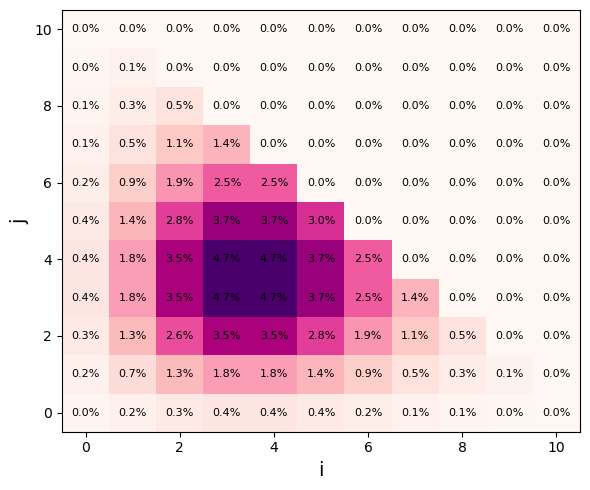

In [14]:
# Plot the theoretical target
plt.figure(figsize=(6, 5))
plt.imshow(prop_theo.T, origin='lower', cmap='RdPu', aspect='auto')

# Add text percentages to the states
for i in range(m + 1):
    for j in range(m + 1):
        val = prop_theo[i, j] * 100
        plt.text(i, j, f"{val:.1f}%", ha='center', va='center', 
                    color='black' if val < 10 else 'white', fontsize=8)

plt.xlabel('i', fontsize=14)
plt.ylabel('j', fontsize=14)
plt.xlim(-0.5, 10.5)
plt.ylim(-0.5, 10.5)
plt.tight_layout()
plt.show()

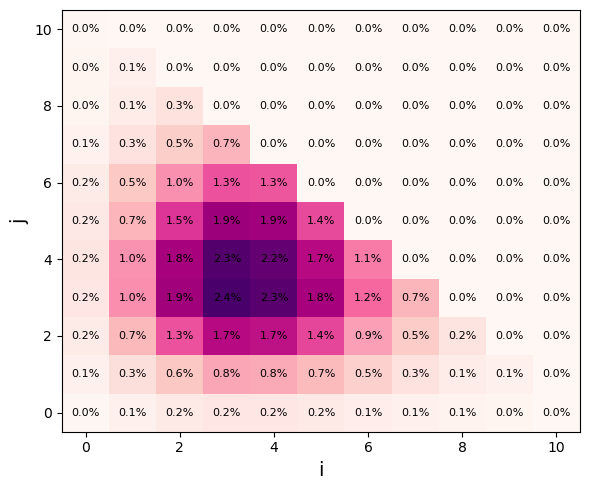

In [15]:
# Heatmap for the samples from the direct MH
obs_freq = np.zeros((m + 1, m + 1))
for i, j in samples_dir_raw:
    obs_freq[i, j] += 1
        
# Convert counts to percentages
empirical_probs = obs_freq / len(samples)   # Divide the raw counts by the total number of samples to get the probability

plt.figure(figsize=(6, 5))
# Drawing the heatmap
plt.imshow(empirical_probs.T, origin='lower', cmap='RdPu', aspect='auto')   # .T transposes the matrix so 'i' is the x-axis and 'j' is the y-axis

# Add text percentages
for i in range(m + 1):
    for j in range(m + 1):
        val = empirical_probs[i, j] * 100   # Convert the decimal probability to a percentage format
        plt.text(i, j, f"{val:.1f}%", ha='center', va='center', 
                    color='black', fontsize=8)

# Layout formatting
plt.xlabel('i', fontsize=14)
plt.ylabel('j', fontsize=14)
plt.xlim(-0.5, 10.5)
plt.ylim(-0.5, 10.5)
plt.tight_layout()
plt.show()

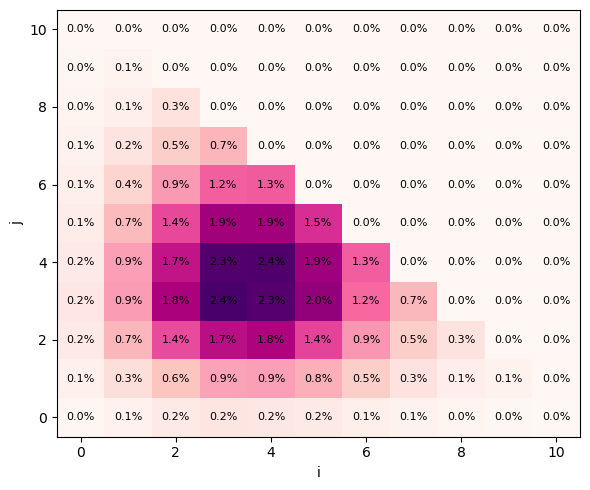

In [16]:
# Heatmap for the samples from the coordinatewise MH
obs_freq = np.zeros((m + 1, m + 1))
for i, j in samples_coor_raw:
    obs_freq[i, j] += 1
        
# Convert counts to percentages
empirical_probs = obs_freq / len(samples)

plt.figure(figsize=(6, 5))
plt.imshow(empirical_probs.T, origin='lower', cmap='RdPu', aspect='auto')

# Add text percentages
for i in range(m + 1):
    for j in range(m + 1):
        val = empirical_probs[i, j] * 100
        plt.text(i, j, f"{val:.1f}%", ha='center', va='center', 
                    color='black', fontsize=8)

plt.xlabel('i')
plt.ylabel('j')
plt.xlim(-0.5, 10.5)
plt.ylim(-0.5, 10.5)
plt.tight_layout()
plt.show()

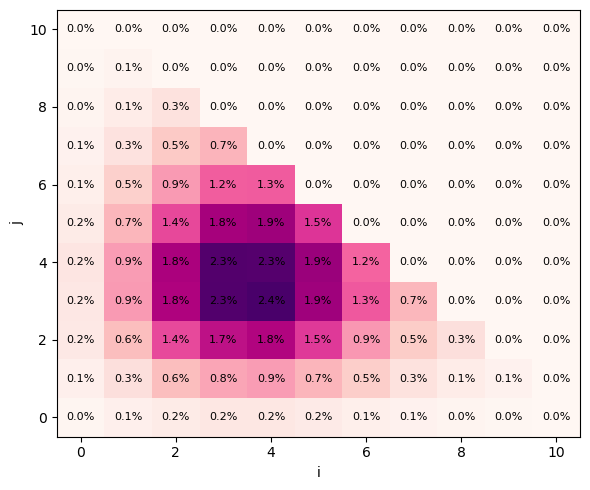

In [17]:
# Heatmap for the samples from the Gibbs method
obs_freq = np.zeros((m + 1, m + 1))
for i, j in samples_gibbs_raw:
    obs_freq[i, j] += 1
        
# Convert counts to percentages
empirical_probs = obs_freq / len(samples)

plt.figure(figsize=(6, 5))
plt.imshow(empirical_probs.T, origin='lower', cmap='RdPu', aspect='auto')

# Add text percentages
for i in range(m + 1):
    for j in range(m + 1):
        val = empirical_probs[i, j] * 100
        plt.text(i, j, f"{val:.1f}%", ha='center', va='center', 
                    color='black', fontsize=8)

plt.xlabel('i')
plt.ylabel('j')
plt.xlim(-0.5, 10.5)
plt.ylim(-0.5, 10.5)
plt.tight_layout()
plt.show()

To make the Chi-square test we again plot the ACF for the MH functions to see when they are no longer significantly dependent

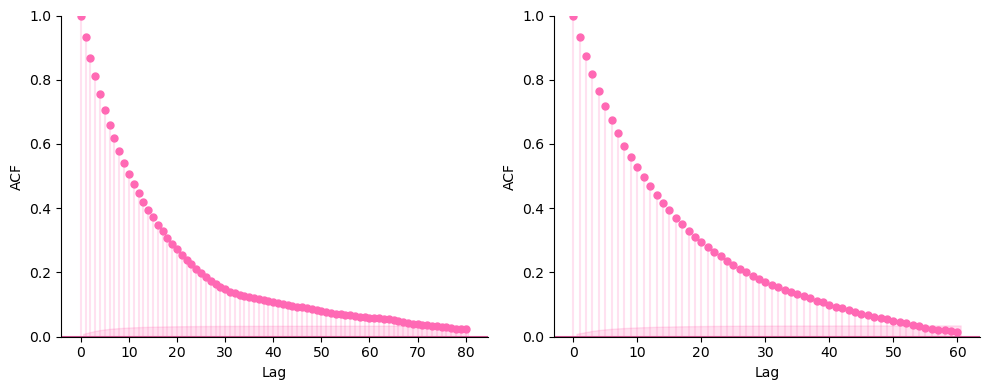

In [18]:
# The ACF for the direct MH method
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Plot ACF for coordinate i on the left subplot (ax[0])
plot_acf(samples_dir_raw[:, 0], lags=80, ax=ax[0], alpha=0.05)

# Plot ACF for coordinate j on the right subplot (ax[1])
plot_acf(samples_dir_raw[:, 1], lags=60, ax=ax[1], alpha=0.05)

for current_ax in ax:
    for line in current_ax.lines:
        line.set_color("hotpink")
    for collection in current_ax.collections:
        collection.set_color("hotpink")
        collection.set_alpha(0.2)

    # Formatting
    current_ax.set_title("")
    current_ax.set_xlabel("Lag")
    current_ax.set_ylabel("ACF")
    current_ax.axhline(0, color='black', linewidth=1)
    
    current_ax.spines['top'].set_visible(False)
    current_ax.spines['right'].set_visible(False)
    
    # No need to show the negative y-axis
    current_ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

Looks like both coordinates are inside the confidence interval at about lag 70, so we will be thinning by using every 70th samplefor the direct method.

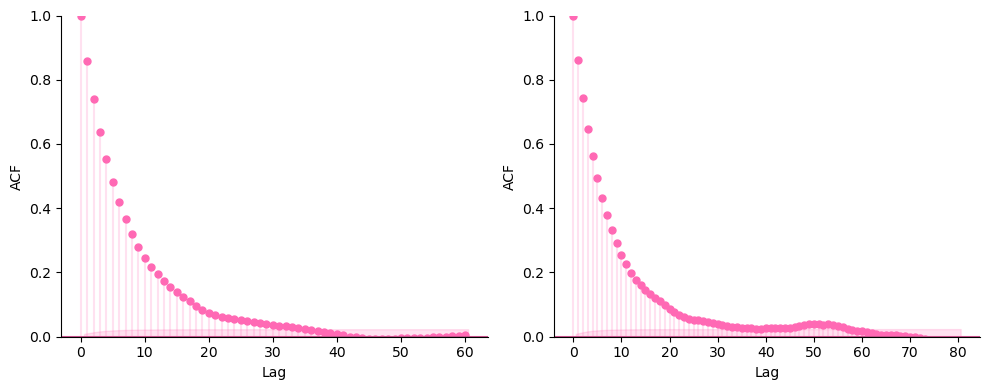

In [19]:
# The ACF for the coordinate wise MH
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Plot ACF for coordinate i on the left subplot (ax[0])
plot_acf(samples_coor_raw[:, 0], lags=60, ax=ax[0], alpha=0.05)

# Plot ACF for coordinate j on the right subplot (ax[1])
plot_acf(samples_coor_raw[:, 1], lags=80, ax=ax[1], alpha=0.05)

for current_ax in ax:
    for line in current_ax.lines:
        line.set_color("hotpink")
    for collection in current_ax.collections:
        collection.set_color("hotpink")
        collection.set_alpha(0.2)

    # Formatting
    current_ax.set_title("")
    current_ax.set_xlabel("Lag")
    current_ax.set_ylabel("ACF")
    current_ax.axhline(0, color='black', linewidth=1)
    
    current_ax.spines['top'].set_visible(False)
    current_ax.spines['right'].set_visible(False)
    
    # No need to show the negative y-axis
    current_ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

Looks like both coordinates are inside the confidence interval after lag 60 for the coordinatewise MH.

In [20]:
# We thin the samples to remove autocorrelation 
samples_dir_test = samples_dir_raw[::70]  # Keep only 1 out of every 70 samples

samples_coor_test = samples_coor_raw[::60]  # Keep only 1 out of every 60 samples

# In Gibbs we do not thin (we use all the samples)
samples_gibbs_test = samples_gibbs_raw[::1] 


# Define a helper function
def run_chi2_test(samples, name):
    print(f"Chi-square test for the method: {name}")
    print(f"Samples used for test: {len(samples)}")
    
    # Observed frequencies
    obs_freq = np.zeros((m + 1, m + 1))
    for i, j in samples:
        obs_freq[i, j] += 1
        
    # We flatten the 2D grid into a 1D array
    obs_flat = obs_freq.flatten()
    exp_flat = (prop_theo * len(samples)).flatten() # Expected count for every state

    valid_mask = exp_flat > 0   # We only test states where the expected probability is > 0
    obs_valid = obs_flat[valid_mask]
    exp_valid = exp_flat[valid_mask]
    
    # Run the test
    chi2_stat, p_val = chisquare(f_obs=obs_valid, f_exp=exp_valid)
    
    print(f"Chi2 Statistic: {chi2_stat:.4f}")
    print(f"P-value:        {p_val:.4f}\n")


# Run the Chi-square test for the three methods
run_chi2_test(samples_dir_test, "Direct Metropolis Hastings")
run_chi2_test(samples_coor_test, "Coordinate wise Metropolis Hastings")
run_chi2_test(samples_gibbs_test, "Gibbs Sampling")

Chi-square test for the method: Direct Metropolis Hastings
Samples used for test: 715
Chi2 Statistic: 68.5024
P-value:        0.3594

Chi-square test for the method: Coordinate wise Metropolis Hastings
Samples used for test: 834
Chi2 Statistic: 57.6965
P-value:        0.7281

Chi-square test for the method: Gibbs Sampling
Samples used for test: 50000
Chi2 Statistic: 59.4716
P-value:        0.6702



We notice that all the p-values are above 0,05 and therefore the null-hypotesis can not be rejected.

## 6.3)
Bayesian statistical problem

### 6.3 a) Generating parameters from the prior distribution

In [21]:
np.random.seed(4223)

# a)
# The prior of (Xi, Gamma) is standard normal with correlation rho = 0,5
mu_prior = [0, 0]   # mean is 0
cov_matrix = [[1.0, 0.5],   # Variance is 1, correlation is 0,5
              [0.5, 1.0]]

# Generating the pair (xi, gamma)
xi, gamma = np.random.multivariate_normal(mu_prior, cov_matrix)

# Transforming to (Theta, Psi) by taking the exponent (since its log)
theta_true = np.exp(xi)
psi_true = np.exp(gamma)

print(f"True Theta:     {theta_true:.4f}")
print(f"True Psi:       {psi_true:.4f}")

True Theta:     1.4085
True Psi:       2.6608


### 6.3 b)
Generate $X_i = 1, . . . , n$ with the values of $(\theta, \psi)$ we obtained in 6.3 a). Use $n=10$.

In [22]:
# We generate n=10 observations from N(Theta, Psi)
n = 10

X_obs = np.random.normal(loc=theta_true, scale=np.sqrt(psi_true), size=n)

# Printing the observations
print(np.round(X_obs, 4))

[-0.1392  0.6642 -0.7608 -0.7298  1.3888 -0.8054  0.0903  0.5097  0.0804
  2.1269]


### 6.3 d) + e)
Generate MCMC samples from the posterior distribution of $(\theta, \psi)$ using the Metropolis Hastings method. For this we use the log-posterior since it is better for large samples. For n= 100, 1000.

True Theta: 1.4085
True Psi:   2.6608

n =   10 | Acceptance Rate: 48.5%
n =  100 | Acceptance Rate: 22.0%
n = 1000 | Acceptance Rate: 4.3%


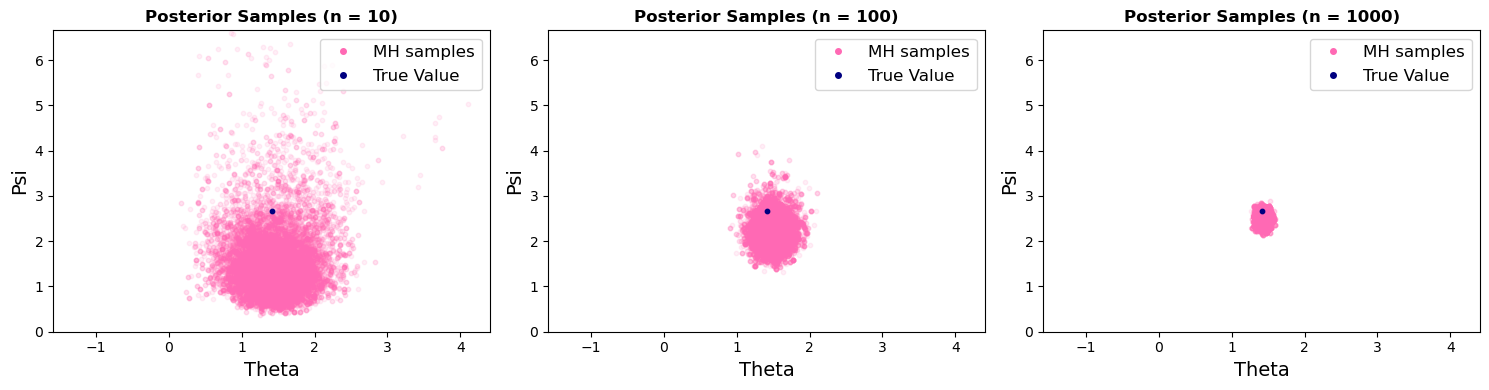

In [23]:
# Define the log-posterior
def log_posterior(theta, psi, n, x_bar, s_sq):
    if theta <= 0 or psi <= 0:  # Theta and Psi must be positive (since they are e^x).
        return -np.inf  # If negative, the probability is 0 (log is -infinity)
    
    term1 = -(n / 2 + 1) * np.log(psi)
    term2 = -np.log(theta)
    term3 = -(np.log(theta)**2 - np.log(theta)*np.log(psi) + np.log(psi)**2) / 1.5
    term4 = -((n - 1) * s_sq + n * (x_bar - theta)**2) / (2 * psi)
    
    return term1 + term2 + term3 + term4

# The Metropolis-Hastings algorithm
def run_mh(n_obs, theta_true, psi_true, num_samples=20000, step_size=0.5):
    # Generate the observations for this specific 'n'
    np.random.seed(4223 + n_obs) # changing the seed sligthly so datasets are unique
    X_obs = np.random.normal(loc=theta_true, scale=np.sqrt(psi_true), size=n_obs)
    
    # Calculate mean and variance
    x_bar = np.mean(X_obs)
    s_sq = np.var(X_obs, ddof=1)
    if n_obs == 1: s_sq = 0 # Handle edge case if n=1
    
    # Initialize the chain
    chain = np.zeros((num_samples, 2))
    
    # Start at the sample mean and sample variance
    curr_theta = x_bar
    curr_psi = s_sq if s_sq > 0 else 1.0 
    curr_log_p = log_posterior(curr_theta, curr_psi, n_obs, x_bar, s_sq)
    
    accepted = 0
    
    for i in range(num_samples):
        # Propose a new state using a random walk (Normal distribution)
        prop_theta = np.random.normal(curr_theta, step_size)
        prop_psi = np.random.normal(curr_psi, step_size)
        
        prop_log_p = log_posterior(prop_theta, prop_psi, n_obs, x_bar, s_sq)
        
        # Calculate acceptance probability in log-scale
        log_alpha = prop_log_p - curr_log_p
        
        # Accept or reject
        if np.log(np.random.rand()) < log_alpha:
            curr_theta = prop_theta
            curr_psi = prop_psi
            curr_log_p = prop_log_p
            accepted += 1
            
        chain[i] = [curr_theta, curr_psi]
        
    print(f"n = {n_obs:4d} | Acceptance Rate: {accepted/num_samples * 100:.1f}%")
    return chain

# Printing the parameter values
print(f"True Theta: {theta_true:.4f}")
print(f"True Psi:   {psi_true:.4f}\n")

# Run the simulations (ignoring the first 20% as burn-in)
burn_in_63=4000
chain_10 = run_mh(10, theta_true, psi_true)[burn_in_63:]
chain_100 = run_mh(100, theta_true, psi_true)[burn_in_63:]
chain_1000 = run_mh(1000, theta_true, psi_true)[burn_in_63:]

from matplotlib.lines import Line2D
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Function to plot a 2D scatter of the samples
def plot_chain(ax, chain, n_val):
    # The samples
    ax.scatter(chain[:, 0], chain[:, 1], alpha=0.1, color='hotpink', s=10, label='MH samples')
    
    # The true values marked as navy blue points
    ax.scatter(theta_true, psi_true, color='navy', s=10, zorder=5, label='True Value')
    
    ax.set_title(f"Posterior Samples (n = {n_val})", fontweight='bold')
    ax.set_xlabel('Theta', fontsize=14)
    ax.set_ylabel('Psi', fontsize=14)
    
    # Setting the axis
    ax.set_xlim(theta_true - 3, theta_true + 3)
    ax.set_ylim(max(0, psi_true - 4), psi_true + 4)

    # Formatting the legends
    legend_handles = [
        Line2D([], [], marker='o', linestyle='None',
            color='hotpink', markersize=4,
            label='MH samples'),
        Line2D([], [], marker='o', linestyle='None',
            color='navy', markersize=4,
            label='True Value')
    ]
    ax.legend(handles=legend_handles, loc='upper right', fontsize=12)

plot_chain(axes[0], chain_10, 10)
plot_chain(axes[1], chain_100, 100)
plot_chain(axes[2], chain_1000, 1000)

plt.tight_layout()
plt.show()